This code requires the huracanpy package

In [6]:
import sys
import os
import huracanpy
import huracanpy.diags
import huracanpy.utils
import huracanpy.utils.category as category
import huracanpy.utils.geography as geography
import huracanpy.utils.time as time
import huracanpy.diags.climato
from huracanpy.diags.track_stats import extremum_vals
from huracanpy.diags.etc_diagnostics import make_longs_cyclic_counts
from huracanpy.diags.etc_diagnostics import make_track_density_lines
from huracanpy.diags.climato import freq_nomean
from huracanpy.diags.etc_plots import etc_stats
from huracanpy.diags.etc_plots import feature_density
from huracanpy.diags.etc_plots import plot_season_basin_gen
from huracanpy.diags.etc_plots import plot_season_basin_all
from huracanpy.diags.etc_plots import etc_interannual
from huracanpy.diags.etc_plots import etc_interannual_many
from huracanpy.diags.etc_plots import plot_points
from huracanpy.diags.etc_plots import plot_tracks
import huracanpy._data._TRACK as TRACK
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle

import datetime
import cftime
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import seaborn as sns
import pandas as pd


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

# storm tracking code - run on spice (HPC) as too heavy for any VDI environment

### storm tracks and stats, for all storms associated with compound events and that cross any area surrounding the UK

In [ ]:

def _ensure_dataset(obj):
    # unwrap common xarray groupby wrappers to the underlying Dataset
    obj = getattr(obj, "obj", obj)
    obj = getattr(obj, "_obj", obj)
    return obj

def _ensure_dataset_with_season(ds, default_season="JJA"):
    ds = _ensure_dataset(ds)
    # i expect an xarray.Dataset
    # add required coordinates if missing
    if "season_etc" not in ds:
        ds = add_cols(
            ds,
            suitenumberin=0,
            suitenamein="",
            membernumberin=0,
            scenarionamein="",
            resolutionin="",
            periodin="",
            seasonin=default_season,
        )
    if "climate_season_year" not in ds:
        ds = add_climate_season_year(ds)
    return ds


def add_climate_season_year(datain, calendar=None):
    """
    add climate seasons
    """
    tracks = datain.groupby("track_id")
    if calendar is None:
        data_subset = []
        for track_id, data_id in tracks:
            # get all the years for this track
            years_id = data_id.year
            months_id = data_id.month
            # print("years", years_id)
            # copy lat to make a blank array
            climate_season_year_id = data_id["lat"].values.copy()
            # fill in all points with the max year for this track
            # this sets Dec from year-1 to same year as Jan and Feb for DJF
            # it track is only in Dec, need to add one to year
            climate_year = years_id.max()
            if months_id[-1] == 12:
                climate_year = climate_year + 1
            climate_season_year_id[:] = climate_year
            # now make into an xarray
            climate_season_year_xr = xr.DataArray(climate_season_year_id, dims="record")
            # add to the data
            data_id["climate_season_year"] = climate_season_year_xr
            # append this track
            data_subset.append(data_id)
        # make into a single dataset
        data = xr.concat(data_subset, dim="record")
    return data

# function to check if a storm overlaps with any compound window
def storm_overlaps_compound_windows(storm_times, compound_windows):
    for _, window in compound_windows.iterrows():
        start = window['start_datetime']
        end = window['end_datetime']
        
        # Check if any storm time falls within this window
        for storm_time in storm_times:
            if start <= storm_time <= end:
                return True
    return False

def adjust_date(date, offset = 15):
    year = int(date[:4])
    month = int(date[4:6])
    day = int(date[6:])

    day += offset
    if day > 30:
        day = day -30
        month += 1
    elif day < 1:
        day = 30 + day #day is negative, so (+) to avoid positive from double negative
        month -= 1

    if month > 12:
        month = 1
        year += 1
    elif month < 1:
        month = 12
        year -= 1

    return f'{year:04d}{month:02d}{day:02d}'

def add_cols(datain, suitenumberin=0, suitenamein="", membernumberin=0, scenarionamein="", resolutionin="", periodin="", seasonin="", calendar=None):
    """
    add extra cols
    """
    # copy a variable
    suite = datain.vorticity.copy()
    # set it to suite number everywhere
    suite[:] = suitenumberin
    # add it as an extra coordinate and change from a coordinate to a variable
    datain = datain.assign_coords(suite=suite).reset_coords("suite")

    # suite name
    suitename = datain.basin.copy()
    suitename[:] = suitenamein
    datain = datain.assign_coords(suitename=suitename).reset_coords("suitename")

    # copy a variable
    membernumber = datain.vorticity.copy()
    # set it to member number everywhere
    membernumber[:] = membernumberin
    # add it as an extra coordinate and change from a coordinate to a variable
    datain = datain.assign_coords(membernumber=membernumber).reset_coords("membernumber")
    
    # scenario
    scenarioname = datain.basin.copy()
    scenarioname[:] = scenarionamein
    datain = datain.assign_coords(scenarioname=scenarioname).reset_coords("scenarioname")

    # resolution
    resolution = datain.basin.copy()
    resolution[:] = resolutionin
    datain = datain.assign_coords(resolution=resolution).reset_coords("resolution")

    # season
    season_etc = datain.basin.copy()
    season_etc[:] = seasonin
    datain = datain.assign_coords(season_etc=season_etc).reset_coords("season_etc")
    
    # period
    period = datain.basin.copy()
    period[:] = periodin
    datain = datain.assign_coords(period=period).reset_coords("period")

    # add extra basins
    lat_name = "lat"
    lon_name = "lon"
    ukbasin = datain.basin.copy()
    ukbasin_value = geography.get_basin(datain[lon_name], datain[lat_name], convention="ETCUK")
    datain = datain.assign_coords(ukbasin=ukbasin_value).reset_coords("ukbasin")
    ns30basin = datain.basin.copy()
    ns30basin_value = geography.get_basin(datain[lon_name], datain[lat_name], convention="ETC30")
    datain = datain.assign_coords(ns30basin=ns30basin_value).reset_coords("ns30basin")

    # add time as year, month, day, hour
    timevalues = time.expand_time(datain, time_name="time")
    
    return datain

def string_to_cftime(date_str, calendar='360_day'):
    """Convert YYYYMMDD string to cftime datetime object"""
    year = int(date_str[:4])
    month = int(date_str[4:6])
    day = int(date_str[6:8])
    return cftime.datetime(year, month, day, 0, 0, 0, 0, calendar=calendar, has_year_zero=True)

# Process all ensemble members and store results in dictionaries

ensembles = ['2335', '1649', '0000', '1554', '1843', '1935', '2123', '2242', '2305', '2491', '2868', '1113']
seasons = ['jja', 'son']

# Dictionaries to store results for each ensemble
results = {
    'tden_storms_uk_1979_2020': {},
    'tden_storms_uk_2040_2079': {},
    'storm_density_1979_2020': {},
    'storm_density_2040_2079': {},
    'storm_density_difference': {},
    'data_uk_only_1979_2020': {},
    'data_uk_only_2040_2079': {},
}

for ensemble in ensembles:
    print(f"\n{'='*50}")
    print(f"Processing ensemble: {ensemble}")
    print(f"{'='*50}")
    
    # Build file paths for this ensemble
    ap977_files = []
    ar095_files = []
    au084_files = []
    
    for year in range(1979, 2006): 
        for season in seasons:
            stash = 'ap977'
            path_file = f'path/to/your/storm/track/files/'
            ap977_files.append(path_file)

    for year in range(2006, 2077):
        for season in seasons:
            stash = 'ar095'
            path_file = f'path/to/your/storm/track/files/'
            ar095_files.append(path_file)

    for year in range(2077, 2080):
        for season in seasons:
            stash = 'au084'
            path_file = f'path/to/your/storm/track/files/'
            au084_files.append(path_file)

    # Load compound events for this ensemble
    compound_start_date = pd.read_csv(f'path/to/your/compound/events/csv/files/')
    compound_jja = compound_start_date[compound_start_date['start_date'].astype(str).str[4:6].isin(['06','07','08', '09'])]
    compound_filtered = compound_jja[compound_jja['extreme_days'] >= 2]
    compound_all = compound_filtered[['start_date', 'length_days']].dropna()
    
    compound_start = compound_all.apply(lambda row: adjust_date(str(row['start_date']), offset=-1), axis=1)
    compound_end = compound_all.apply(lambda row: adjust_date(str(row['start_date']), offset=(row['length_days'] - 1)), axis=1)
    compound_window_df = pd.DataFrame({'start_date': compound_start, 'end_date': compound_end})
    compound_window_df['start_datetime'] = compound_window_df['start_date'].apply(lambda x: string_to_cftime(str(x)))
    compound_window_df['end_datetime'] = compound_window_df['end_date'].apply(lambda x: string_to_cftime(str(x)))

    # Load all storms
    all_storms = []
    track_id_first_track = 0
    
    for file_path in ap977_files:
        try:
            storm = TRACK.load(file_path, calendar='360_day', track_id_first_track=track_id_first_track)
            track_id_first_track = track_id_first_track + np.max(storm.track_id) + 1
            all_storms.append(storm)
        except Exception as e:
            print(f"Warning: Could not load {file_path}: {e}")

    for file_path in ar095_files:
        try:
            storm = TRACK.load(file_path, calendar='360_day', track_id_first_track=track_id_first_track)
            track_id_first_track = track_id_first_track + np.max(storm.track_id) + 1
            all_storms.append(storm)
        except Exception as e:
            print(f"Warning: Could not load {file_path}: {e}")

    for file_path in au084_files:
        try:
            storm = TRACK.load(file_path, calendar='360_day', track_id_first_track=track_id_first_track)
            track_id_first_track = track_id_first_track + np.max(storm.track_id) + 1
            all_storms.append(storm)
        except Exception as e:
            print(f"Warning: Could not load {file_path}: {e}")

    if len(all_storms) == 0:
        print(f"No storms loaded for ensemble {ensemble}, skipping...")
        continue

    all_storms_combined = xr.concat(all_storms, dim='record')

    # Filter for storms overlapping with compound windows
    compound_and_storms = []
    unique_track_ids = np.unique(all_storms_combined['track_id'].values)

    for track_id in unique_track_ids:
        track_mask = all_storms_combined['track_id'].values == track_id
        track_times = all_storms_combined['time'].values[track_mask]
        if storm_overlaps_compound_windows(track_times, compound_window_df):
            compound_and_storms.append(all_storms_combined.isel(record=track_mask))

    print(f"Total filtered storms: {len(compound_and_storms)}")

    if len(compound_and_storms) == 0:
        print(f"No compound storms found for ensemble {ensemble}, skipping...")
        continue

    compound_and_storm_filtered = xr.concat(compound_and_storms, dim='record')

    # Filter by time period
    mask_1979_2020 = (compound_and_storm_filtered['time'].dt.year >= 1979) & (compound_and_storm_filtered['time'].dt.year <= 2020)
    CS_1979_2020 = compound_and_storm_filtered.isel(record=mask_1979_2020)
    
    mask_2040_2079 = (compound_and_storm_filtered['time'].dt.year >= 2040) & (compound_and_storm_filtered['time'].dt.year <= 2079)
    CS_2040_2079 = compound_and_storm_filtered.isel(record=mask_2040_2079)

    # Get UK storms for each period
    CS_all_info_uk_1979_2020 = huracanpy.utils.add_all_info(CS_1979_2020, lat_name="lat", lon_name="lon", wind_name=None, slp_name=None, slp_units="hPa", basin_convention="ETCUK", calendar="360_day")
    CS_all_info_uk_1979_2020 = add_cols(CS_all_info_uk_1979_2020, suitenumberin=0, suitenamein="ap977", membernumberin=int(ensemble), scenarionamein="", seasonin="JJA", resolutionin="N96", periodin="1979-2020")
    CS_all_info_uk_1979_2020 = add_climate_season_year(CS_all_info_uk_1979_2020)
    tracks_uk_1979_2020 = CS_all_info_uk_1979_2020.groupby("track_id")

    CS_all_info_uk_2040_2079 = huracanpy.utils.add_all_info(CS_2040_2079, lat_name="lat", lon_name="lon", wind_name=None, slp_name=None, slp_units="hPa", basin_convention="ETCUK", calendar="360_day")
    CS_all_info_uk_2040_2079 = add_cols(CS_all_info_uk_2040_2079, suitenumberin=0, suitenamein="ar095", membernumberin=int(ensemble), scenarionamein="", seasonin="JJA", resolutionin="N96", periodin="2040-2079")
    CS_all_info_uk_2040_2079 = add_climate_season_year(CS_all_info_uk_2040_2079)
    tracks_uk_2040_2079 = CS_all_info_uk_2040_2079.groupby("track_id")

    # Filter UK-only tracks
    data_uk_1979_2020 = []
    for tracki, datai in tracks_uk_1979_2020:
        iiuk = np.where(datai.basin.values == "ETCUK")[0]
        if len(iiuk) > 1:
            data_uk_1979_2020.append(datai)
    
    data_uk_2040_2079 = []
    for tracki, datai in tracks_uk_2040_2079:   
        iiuk = np.where(datai.basin.values == "ETCUK")[0]
        if len(iiuk) > 1:
            data_uk_2040_2079.append(datai)

    print(f"UK tracks 1979-2020: {len(data_uk_1979_2020)}, 2040-2079: {len(data_uk_2040_2079)}")

    if len(data_uk_1979_2020) == 0 or len(data_uk_2040_2079) == 0:
        print(f"Insufficient UK tracks for ensemble {ensemble}, skipping...")
        continue

    data_uk_only_1979_2020 = xr.concat(data_uk_1979_2020, dim="record")
    data_uk_only_2040_2079 = xr.concat(data_uk_2040_2079, dim="record")

    # Ensure datasets have required columns
    data_uk_only_1979_2020 = _ensure_dataset_with_season(data_uk_only_1979_2020, default_season="JJA")
    data_uk_only_2040_2079 = _ensure_dataset_with_season(data_uk_only_2040_2079, default_season="JJA")

    # Calculate track densities
    _, _, tden_uk_1979_2020, _ = make_track_density_lines(data_uk_only_1979_2020, number_of_years=1)
    tden_storms_uk_1979_2020 = tden_uk_1979_2020.copy()

    _, _, tden_uk_2040_2079, _ = make_track_density_lines(data_uk_only_2040_2079, number_of_years=1)
    tden_storms_uk_2040_2079 = tden_uk_2040_2079.copy()

    # Calculate normalised densities and differences
    storm_density_1979_2020 = tden_storms_uk_1979_2020 / np.max(tden_storms_uk_1979_2020)
    storm_density_2040_2079 = tden_storms_uk_2040_2079 / np.max(tden_storms_uk_2040_2079)
    storm_density_difference = storm_density_2040_2079 - storm_density_1979_2020

    # Store results in dictionaries
    results['tden_storms_uk_1979_2020'][ensemble] = tden_storms_uk_1979_2020
    results['tden_storms_uk_2040_2079'][ensemble] = tden_storms_uk_2040_2079
    results['storm_density_1979_2020'][ensemble] = storm_density_1979_2020
    results['storm_density_2040_2079'][ensemble] = storm_density_2040_2079
    results['storm_density_difference'][ensemble] = storm_density_difference
    results['data_uk_only_1979_2020'][ensemble] = data_uk_only_1979_2020
    results['data_uk_only_2040_2079'][ensemble] = data_uk_only_2040_2079

#  results to a pickle file
output_path = 'path/to/save/your/results.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(results, f)

# calculate ivt anomaly along the ivt anomaly along the selected storm track

In [ ]:
def filter_tracks_by_bbox(tracks_groupby, lat_min, lat_max, lon_min, lon_max):
    """
    Extract only the portions of tracks that fall within the bounding box.
    
    Parameters:
    -----------
    tracks_groupby : DatasetGroupBy object
    lat_min, lat_max : float
        Latitude bounds
    lon_min, lon_max : float
        Longitude bounds
    
    Returns:
    --------
    xarray.Dataset : Combined dataset with only points inside bounding box
    """
    filtered_tracks = []
    
    for track_id, track_data in tracks_groupby:
        # get lat/lon values
        lats = track_data['lat'].values
        lons = track_data['lon'].values
        
        # nomalise lons if needed (convert to -180 to 180 range)
        lons_normalized = np.where(lons > 180, lons - 360, lons)
        
        # createmask for points within bounding box
        mask = (
            (lats >= lat_min) & (lats <= lat_max) &
            (lons_normalized >= lon_min) & (lons_normalized <= lon_max))
        
        # only keep this track if it has at least one point in the box
        if mask.any():
            filtered_track = track_data.isel(record=mask)
            filtered_tracks.append(filtered_track)
    
    # concte all filtered tracks
    if filtered_tracks:
        return xr.concat(filtered_tracks, dim='record')
    else:
        return None

# exatrctthe tracka nd coords for each track
def extract_track_coords_and_times(tracks_groupby):
    """
    Extract lon, lat, and time for each track.
    Returns a dictionary: {track_id: {'lon': array, 'lat': array, 'time': array}}
    """
    track_info = {}
    
    for track_id, track_data in tracks_groupby:
        track_info[track_id] = {
            'lon': track_data['lon'].values,
            'lat': track_data['lat'].values,
            'time': track_data['time'].values
        }
    
    return track_info

def sample_ivt_along_tracks(track_info, ivt_data):
    """
    Sample IVT anomaly values along each storm track.
    
    Parameters:
    -----------
    track_info : dict from extract_track_coords_and_times()
    ivt_data : xarray DataArray with IVT anomalies (dims: time, latitude, longitude)
    
    Returns:
    --------
    dict: {track_id: {'lon': array, 'lat': array, 'time': array, 'ivt': array}}
    """
    track_ivt = {}
    
    for track_id, info in track_info.items():
        lons = info['lon']
        lats = info['lat']
        times = info['time']
        
        ivt_values = []
        for i in range(len(lons)):
            try:
                # Normalise longitude to match IVT data range (-180 to 180)
                lon_i = lons[i]
                if lon_i > 180:
                    lon_i = lon_i - 360
                
                # Select IVT at this location and time using correct coord names
                ivt_val = ivt_data.sel(
                    time=times[i],
                    latitude=lats[i],
                    longitude=lon_i,
                    method='nearest'
                ).values
                ivt_values.append(float(ivt_val))
            except Exception as e:
                ivt_values.append(np.nan)
        
        track_ivt[track_id] = {
            'lon': lons,
            'lat': lats,
            'time': times,
            'ivt': np.array(ivt_values)
        }
    
    return track_ivt

def dict_to_xarray(track_ivt_dict):
    """convert track dictionary to xarray Dataset for saving"""
    datasets = []
    for track_id, data in track_ivt_dict.items():
        n_points = len(data['lon'])
        ds = xr.Dataset({
            'lon': (['point'], data['lon']),
            'lat': (['point'], data['lat']),
            'time': (['point'], data['time']),
            'ivt': (['point'], data['ivt'])
        }, coords={'track_id': track_id})
        datasets.append(ds)
    return xr.concat(datasets, dim='track_id')
#----------------------------------------------------------------------------------------------------
ensembles_dict = {'0000',
                  '1113',
                  '1554',
                  '1649',
                  '1843',
                  '1935',
                  '2123',
                  '2242',
                  '2305',
                  '2335',
                  '2491',
                  '2868'}


save_dir = 'path/to/save/your/tracks'

for ensemble in ensembles_dict:
    # Load xarray datasets
    data_uk_only           = xr.open_dataset(f'{save_dir}/data_uk_only_{ensemble}.nc')
    data_uk_only_1979_2020 = xr.open_dataset(f'{save_dir}/data_uk_only_1979_2020_{ensemble}.nc')
    data_uk_only_2040_2079 = xr.open_dataset(f'{save_dir}/data_uk_only_2040_2079_{ensemble}.nc')

    CS_all_info            = xr.open_dataset(f'{save_dir}/CS_all_info_{ensemble}.nc')
    CS_all_info_1979_2020  = xr.open_dataset(f'{save_dir}/CS_all_info_1979_2020_{ensemble}.nc')
    CS_all_info_2040_2079  = xr.open_dataset(f'{save_dir}/CS_all_info_2040_2079_{ensemble}.nc')

    # Recreate groupbys (these can't be saved, but are trivial to recreate)
    tracks_uk_only_1979_2020 = data_uk_only_1979_2020.groupby("track_id")
    tracks_uk_only_2040_2079 = data_uk_only_2040_2079.groupby("track_id")

    lat_min, lat_max = 30, 51
    lon_min, lon_max = -81, -42

    #tracks of storms that pass through uk dring compound, and only the points of those tracks that are within the bounding box (along US coast)
    tracks_uk_bbox_1979_2020 = filter_tracks_by_bbox(tracks_uk_only_1979_2020, lat_min, lat_max, lon_min, lon_max)
    tracks_uk_bbox_2040_2079 = filter_tracks_by_bbox(tracks_uk_only_2040_2079,lat_min, lat_max,lon_min, lon_max)

    # getting the ivt anom data
    IVT_anomaly_1980_20 = iris.load_cube(f'/path/to/your/ivt/anomaly/files/')
    IVT_anomaly_1980_20_xr = xr.DataArray.from_iris(IVT_anomaly_1980_20)

    IVT_anomaly_2040_80 = iris.load_cube(f'/path/to/your/ivt/anomaly/files/')
    IVT_anomaly_2040_80_xr = xr.DataArray.from_iris(IVT_anomaly_2040_80)

    uk_tracks_1979_2020 = extract_track_coords_and_times(tracks_uk_only_1979_2020)
    uk_tracks_2040_2079 = extract_track_coords_and_times(tracks_uk_only_2040_2079)


    # Sample IVT along UK tracks
    uk_tracks_ivt_1979_2020 = sample_ivt_along_tracks(uk_tracks_1979_2020, IVT_anomaly_1980_20_xr)
    uk_tracks_ivt_2040_2079 = sample_ivt_along_tracks(uk_tracks_2040_2079, IVT_anomaly_2040_80_xr)

    save_dir = 'path/to/save/your/tracks'

    uk_ivt_1979_2020_xr = dict_to_xarray(uk_tracks_ivt_1979_2020)
    uk_ivt_1979_2020_xr.to_netcdf(f'{save_dir}/uk_tracks_ivt_1979_2020_{ensemble}.nc')

    uk_ivt_2040_2079_xr = dict_to_xarray(uk_tracks_ivt_2040_2079)
    uk_ivt_2040_2079_xr.to_netcdf(f'{save_dir}/uk_tracks_ivt_2040_2079_{ensemble}.nc')


# plot IVT anomaly along the selected storm tracks for all members 

/var/tmp/ipykernel_1360231/2475106912.py:87: RuntimeWarning: Mean of empty slice
  ivt_ensemble_mean_diff = np.nanmean(ivt_diff_all, axis=0)


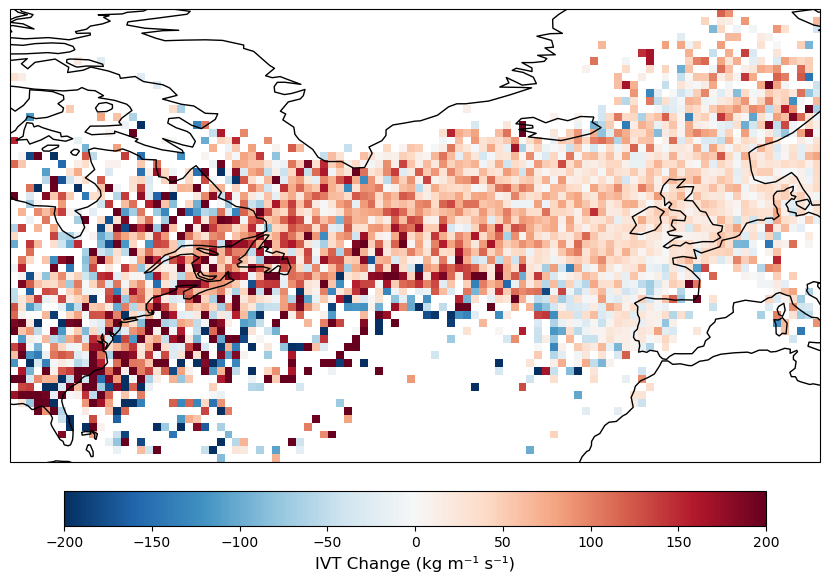


=== ENSEMBLE MEAN DIFFERENCE STATISTICS ===
Ensemble mean IVT change: 44.07 kg m⁻¹ s⁻¹
Max increase: 838.56 kg m⁻¹ s⁻¹
Max decrease: -790.10 kg m⁻¹ s⁻¹


In [5]:
ensembles = ['2335','1649','0000','1554','1843','1935','2123','2242','2305','2491','2868','1113']

# def bins with higher resolution (smaller grid cells)
lat_bins = np.arange(23, 81, 1.0)  # 1.0 degree resolution
lon_bins = np.arange(-88, 15, 1.0)  # 1.0 degree resolution

# fction to bin IVT values onto grid
def bin_ivt_to_grid(lats, lons, ivt_vals, lat_bins, lon_bins):
    # flatten arrays and remove nans
    lats_flat = lats.flatten()
    lons_flat = lons.flatten()
    ivt_flat = ivt_vals.flatten()
    
    mask = ~np.isnan(ivt_flat)
    lats_flat = lats_flat[mask]
    lons_flat = lons_flat[mask]
    ivt_flat = ivt_flat[mask]
    
    # normalise lons to -180 to 180
    lons_flat = np.where(lons_flat > 180, lons_flat - 360, lons_flat)
    
    # 2D histogram (sum and count)
    ivt_sum, _, _ = np.histogram2d(lats_flat, lons_flat, bins=[lat_bins, lon_bins], weights=ivt_flat)
    count, _, _ = np.histogram2d(lats_flat, lons_flat, bins=[lat_bins, lon_bins])
    
    # calc mean (avoid division by zero)
    with np.errstate(divide='ignore', invalid='ignore'):
        ivt_mean = np.where(count > 0, ivt_sum / count, np.nan)
    
    return ivt_mean

# meshgrid for plotting
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
LON, LAT = np.meshgrid(lon_centers, lat_centers)

ivt_diff_all = []

for ensemble in ensembles:
    track_1979_2020 = xr.open_dataset(f'/path/to/your/storm/track/anomalies/{ensemble}.nc')
    track_2040_2079 = xr.open_dataset(f'/path/to/your/storm/track/anomalies/{ensemble}.nc')
    
    lat_1979 = track_1979_2020['lat'].values
    lon_1979 = track_1979_2020['lon'].values
    ivt_1979 = track_1979_2020['ivt'].values
    
    lat_2040 = track_2040_2079['lat'].values
    lon_2040 = track_2040_2079['lon'].values
    ivt_2040 = track_2040_2079['ivt'].values
    
#bin the data
    ivt_grid_1979 = bin_ivt_to_grid(lat_1979, lon_1979, ivt_1979, lat_bins, lon_bins)
    ivt_grid_2040 = bin_ivt_to_grid(lat_2040, lon_2040, ivt_2040, lat_bins, lon_bins)
    
    # calc diff (future - past)
    ivt_diff = ivt_grid_2040 - ivt_grid_1979
    
    ivt_diff_all.append(ivt_diff)
    
    #---------- plotting -----------------
    vmax = min(np.nanmax(np.abs(ivt_diff)), 200)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # diff (2040-2079 minus 1979-2020)
    im = ax.pcolormesh(LON, LAT, ivt_diff, cmap='RdBu_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines()
    ax.set_title(f'IVT Change along UK storm tracks (2040-2079 minus 1979-2020), p110{ensemble}', fontsize=14)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    # colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('IVT Change (kg m⁻¹ s⁻¹)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'/home/users/elena.dauster/Documents/python/CoinCalc/storms/ivt_meshgrid_diff_{ensemble}.png', 
                dpi=300, bbox_inches='tight')
    plt.close()
    
# caclc ensemble mean difference
ivt_ensemble_mean_diff = np.nanmean(ivt_diff_all, axis=0)

# plot for ensemble mean difference
vmax = min(np.nanmax(np.abs(ivt_ensemble_mean_diff)), 200)      #cap vmax cause otherwise it just washed out the data, for 5 grid points
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# ensemble mean difference
im = ax.pcolormesh(LON, LAT, ivt_ensemble_mean_diff, cmap='RdBu_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)
ax.coastlines()
#ax.set_title(f'Ensemble Mean IVT Change along UK storm tracks\n(2040-2079 minus 1979-2020, n={len(ensembles)})', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('IVT Change (kg m⁻¹ s⁻¹)', fontsize=12)

plt.tight_layout()
plt.show()

# Print ensemble mean statistics
print(f"\n=== ENSEMBLE MEAN DIFFERENCE STATISTICS ===")
print(f"Ensemble mean IVT change: {np.nanmean(ivt_ensemble_mean_diff):.2f} kg m⁻¹ s⁻¹")
print(f"Max increase: {np.nanmax(ivt_ensemble_mean_diff):.2f} kg m⁻¹ s⁻¹")
print(f"Max decrease: {np.nanmin(ivt_ensemble_mean_diff):.2f} kg m⁻¹ s⁻¹")